## Classificazione degli abbandoni al primo anno - ML

Task: predire l'abbandono degli studenti del primo anno considerando solo le informazioni a disposizione al momento della iscrizione.

## Preprocessing, data visualization, feature engineering

In [ ]:
# path per ide locale

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
import openpyxl as xl

path = r'C:\Users\Utente\PycharmProjects\Data_mining_UPO\data\abb_v3_anonimo_early.xlsx'
df = pd.read_excel(path)

In [1]:
# path per ide colab

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk

from google.colab import drive

drive.mount('/content/drive')
df = pd.read_excel('/content/drive/My Drive/Colab Data/abb_v3_anonimo_early.xlsx')

Mounted at /content/drive


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17221 entries, 0 to 17220
Data columns (total 42 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   età                                     17221 non-null  float64
 1   rango_prossimità                        17221 non-null  float64
 2   sesso                                   17221 non-null  int64  
 3   tipo_cds                                17221 non-null  int64  
 4   accesso_libero                          17221 non-null  int64  
 5   puro                                    17221 non-null  int64  
 6   evento_flag                             17221 non-null  int64  
 7   cittadinanza_ita                        17221 non-null  int64  
 8   capoluogo_residenza                     17221 non-null  int64  
 9   scuola_vs_residenza                     17221 non-null  int64  
 10  L2_tipo_titolo_new_Artistico            17221 non-null  fl

In [2]:
# non mi servono
df.drop(columns=['fakeid', 'Giorno','Data Chiusura','Cittadinanza',
                 'Provincia Domicilio SIGLA' ,'Provincia Domicilio COD', 'Comune Domicilio Catasto COD',
                 'A.A.', 'Dipartimento DESC', 'Tipo Corso di Studi DESC', 'Corsi di Studio DESC', 'Corsi di Studio COD'],
        inplace=True, errors = 'ignore')


# nomi decenti per feature
df.columns = ['età', 'sesso', 'cittadinanza', 'residenza_regione', 'residenza_provincia', 'residenza_comune',
              'domicilio_regione', 'domicilio_provincia', 'domicilio_comune', 'scuola_comune', 'scuola_provincia', 'L1_tipo_titolo', 'L2_tipo_titolo', 'L3_tipo_titolo',
              'voto_titolo', 'lode', 'anno_titolo', 'dipartimento', 'tipo_cds', 'accesso_libero', 'puro', 'abbandono', 'n_eventi', 'evento_flag']

# prevengo i rari errori del dwh che conosco sulla metrica di abbandono
df['abbandono'] = df['abbandono'].apply(lambda x: 1 if x > 1 else x)
df['puro'] = df['puro'].apply(lambda x: 1 if x > 1 else x)

# trasformazione variabili categoriche facili
df['sesso'] = df['sesso'].replace({'M':0, 'F':1})
# visto che i tipi di corso si distinguono per la durata, la trasformo così in var numerica
df['tipo_cds'] = df['tipo_cds'].replace({'L':0, 'LM5':1}).astype(int)
# cittadinanza binaria
df['cittadinanza_ita'] = df['cittadinanza'].apply(lambda x: 1 if x == 'Italiana' else 0)
df = df.drop(columns=['cittadinanza'])

/tmp/ipython-input-3974095842.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sesso'] = df['sesso'].replace({'M':0, 'F':1})
/tmp/ipython-input-3974095842.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['tipo_cds'] = df['tipo_cds'].replace({'L':0, 'LM5':1}).astype(int)


In [3]:
# FEATURE CREATION
# visto che ci sono molte modalità per le variabili geo, provo a creare delle feature riassuntive

# new feature ! RANGO_PROSSIMITÀ !

prov_confinanti = {'Pavia', 'Cremona', 'Milano', 'Alessandria'}

def compute_rango(row):
    # sede
    if (row['dipartimento'] == '091100' and row['residenza_comune'] == 'Cremona') \
       or (row['dipartimento'] != '091100' and row['residenza_comune'] == 'Pavia'):
        return 0
    # residenza province vicine
    elif row['residenza_provincia'] in prov_confinanti:
        return 1
    # resto Lombardia
    elif row['residenza_regione'] == 'Lombardia':
        return 2
    # centro-nord
    elif row['residenza_regione'] in {'Piemonte',"Valle d'Aosta",'Liguria','Trentino-Alto Adige',
                                      'Veneto','Friuli-Venezia Giulia','Emilia-Romagna',
                                      'Toscana','Umbria','Marche','Lazio'}:
        return 3
    #sud e isole
    elif row['residenza_regione'] in {'Abruzzo','Molise','Campania','Puglia','Basilicata',
                                      'Calabria','Sicilia','Sardegna'}:
        return 4
    # Estero o missing
    else:
        return 5

df['rango_prossimità'] = df.apply(compute_rango, axis=1)

# new feature ! CAPOLUOGO_RESIDENZA !

# regola: se comune_residenza == provincia_residenza → capoluogo
# per valutare eventuale vantaggio socio-economico a vivere in capoluogo
df['capoluogo_residenza'] = (df['residenza_comune'] == df['residenza_provincia']).astype(int)

# new feature ! SCUOLA VS RESIDENZA !

# scuola vs residenza: 1 se scuola_provincia == residenza_provincia
df['scuola_vs_residenza'] = (df['scuola_provincia'] == df['residenza_provincia']).astype(int)

# Eliminazione di tutte le colonne relative a variabili geografiche (residenza, domicilio, scuola)
df = df.drop(columns=['residenza_regione','residenza_provincia','residenza_comune',
    'domicilio_regione','domicilio_provincia','domicilio_comune',
    'scuola_provincia','scuola_comune'])

# new feature ! TITOLO NEW !

# var del tipo scuola sono troppo poco o troppo troppo, quindi me la sbrigo facendo mapping da solo

import pandas as pd

# dizionario di mapping
mapping_titolo = {

    # Estero
    "Diploma Estero": "Estero",

    # Magistrali
    "Diploma Magistrale": "Magistrali",
    "Maturita' Magistrale": "Magistrali",

    # Licei
    "Maturita' Classica": "Classico",
    "Maturita' Scientifica": "Scientifico",
    "Maturita' Linguistica": "Linguistico",
    "Maturita' Artistica": "Artistico",

    # Tecnici Economico/Commerciali
    "Ragioniere": "Tecnico_Economico",
    "Perito Tecnico Commerciale": "Tecnico_Economico",
    "Maturita' Tecnico Sociale": "Tecnico_Economico",

    # Tecnici Industriali/Scientifici
    "Perito Tecnico Industriale": "Tecnico_Industriale",
    "Geometra": "Tecnico_Industriale",
    "Perito Agrario": "Tecnico_Industriale",
    "Perito Tecnico Navale": "Tecnico_Industriale",
    "Perito Tecnico Aeronautico": "Tecnico_Industriale",
    "Maturita' Tecnico Artistica": "Tecnico_Industriale",

    # Professionali
    "Maturita' Professionale": "Professionale",

    # Non fornito
    "Non Fornito": "Non_fornito"
}


df["L2_tipo_titolo_new"] = df['L2_tipo_titolo'].map(mapping_titolo).fillna("Non_fornito")

df = df.drop(columns=['L1_tipo_titolo', 'L2_tipo_titolo', 'L3_tipo_titolo'])

print(df["L2_tipo_titolo_new"].value_counts())

L2_tipo_titolo_new
Scientifico            5857
Tecnico_Industriale    2752
Magistrali             1716
Linguistico            1581
Professionale          1408
Classico               1333
Tecnico_Economico      1288
Estero                  931
Artistico               326
Non_fornito              29
Name: count, dtype: int64


EDA / DATA VIZ

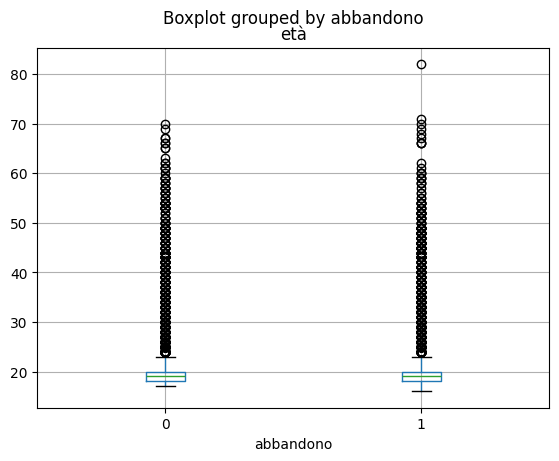

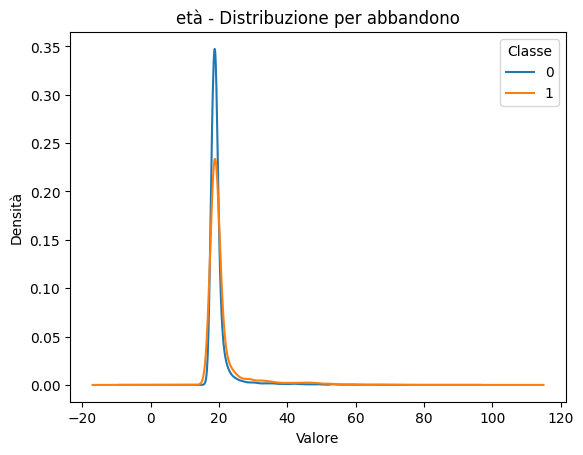

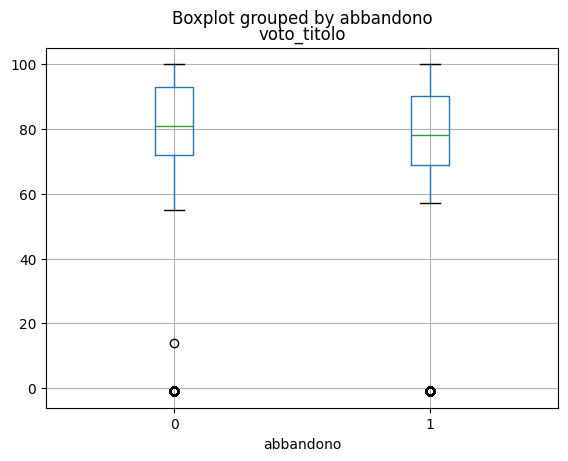

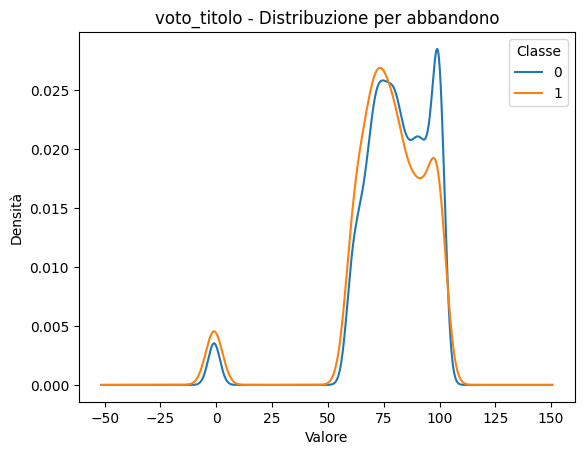

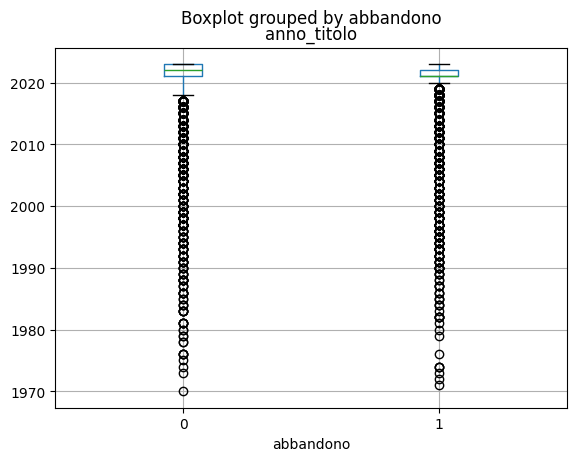

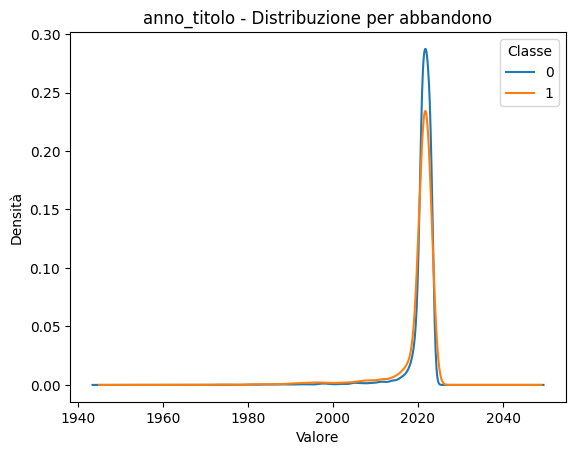

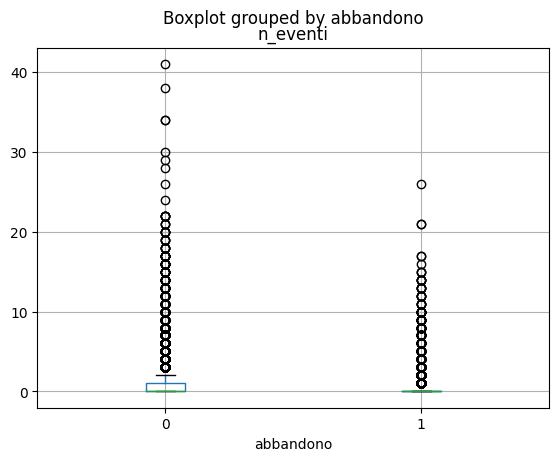

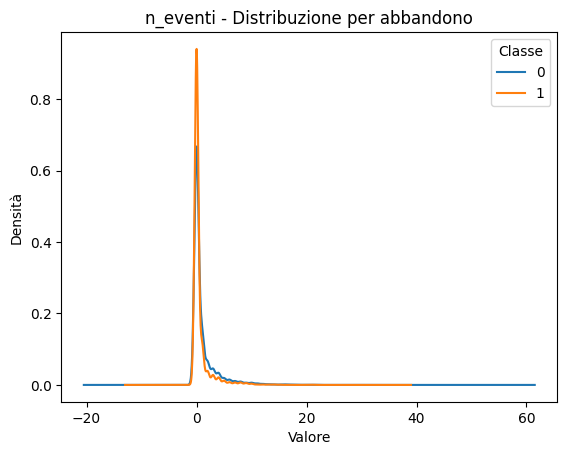

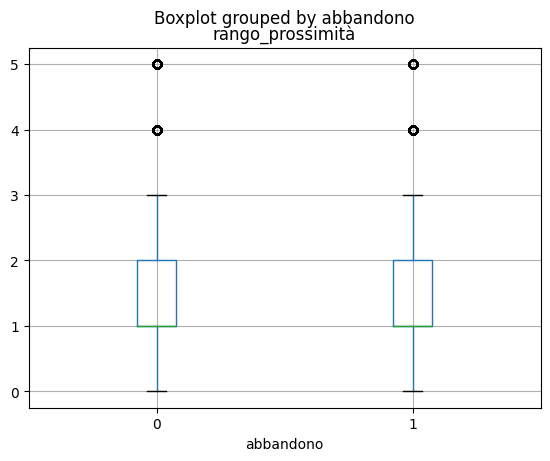

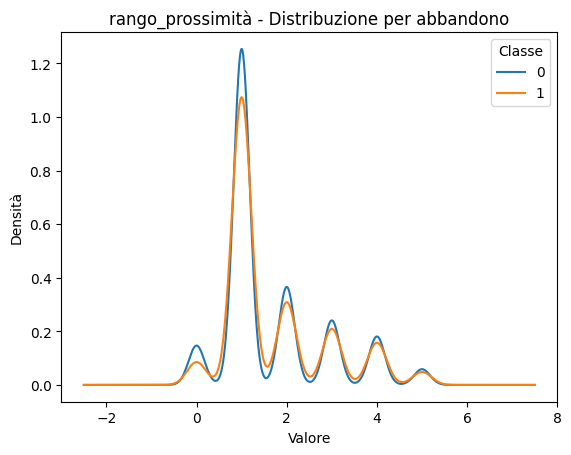

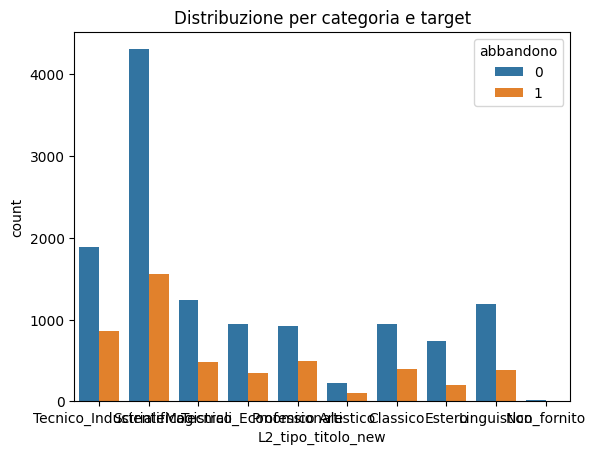

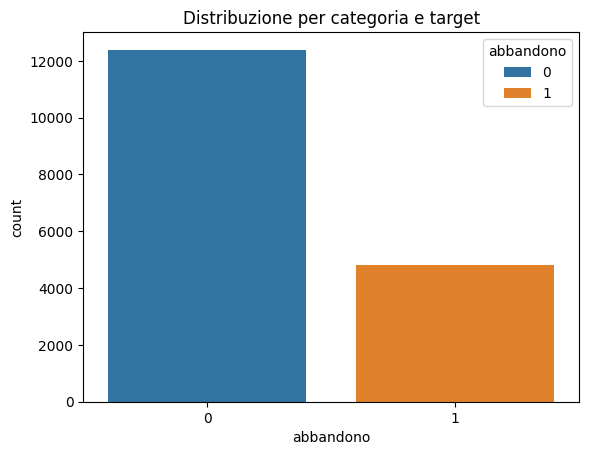

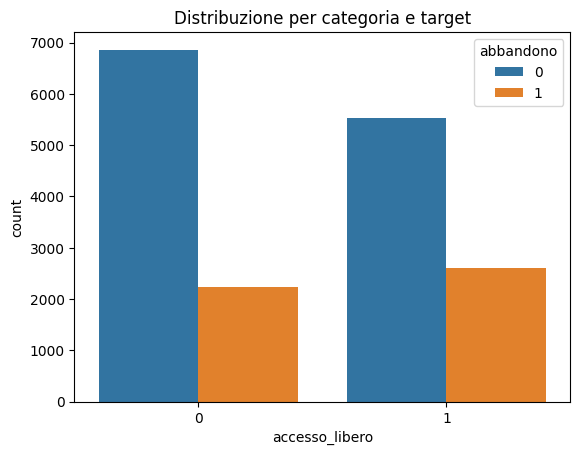

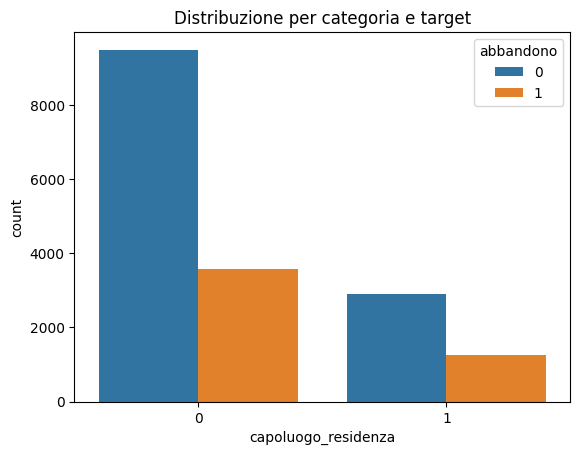

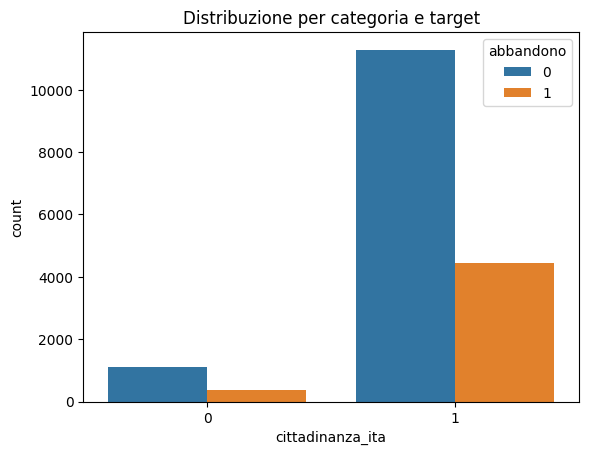

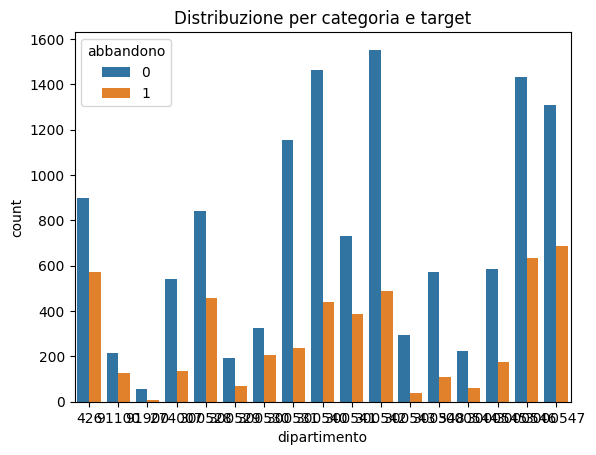

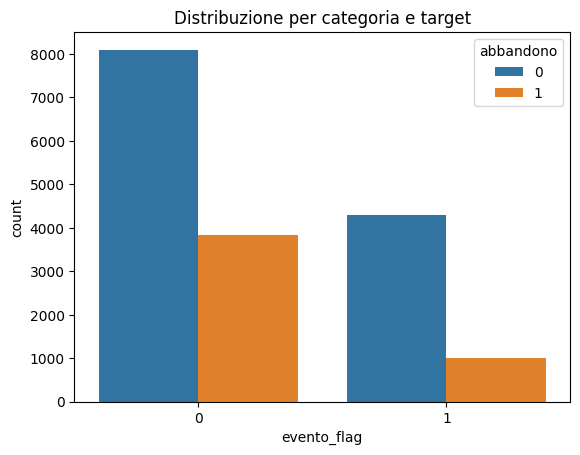

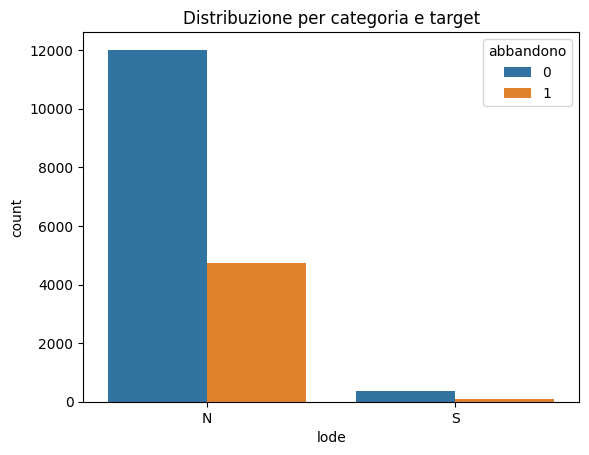

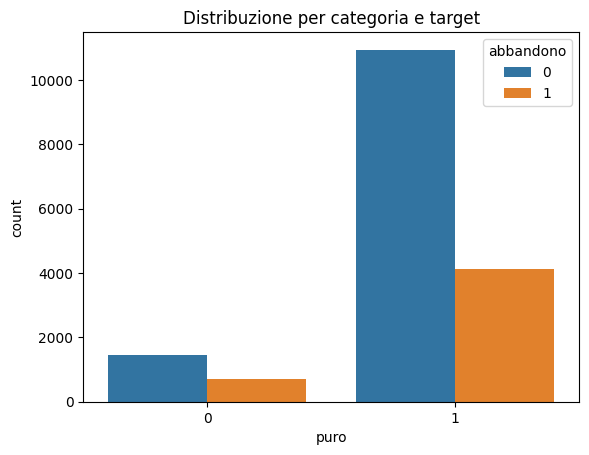

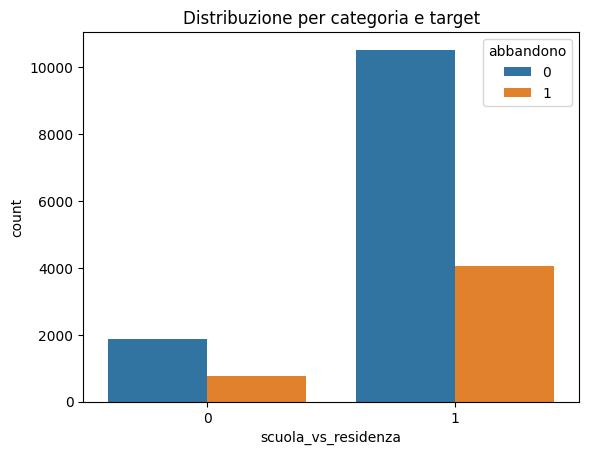

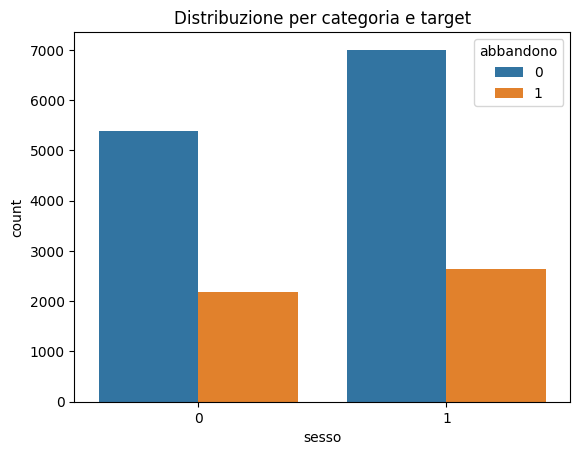

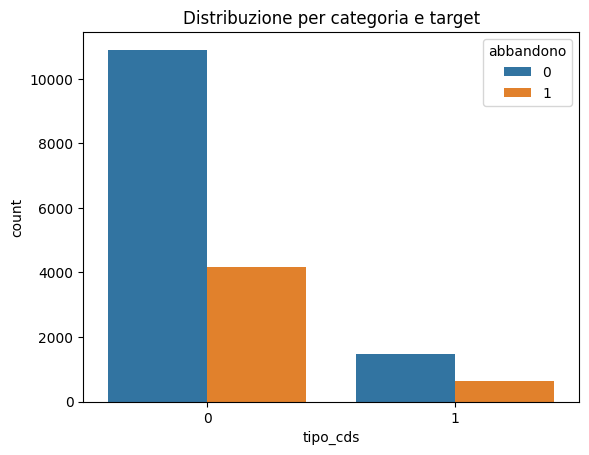

In [ ]:
import math
import seaborn as sns
num_cols = ['età', 'voto_titolo', 'anno_titolo', 'n_eventi', 'rango_prossimità']
cat_cols = df.columns.difference(num_cols)

#fig,ax = plt.subplots(len(num_cols), 1, figsize=(10,10))
for col in num_cols:
    df.boxplot(column=col,by='abbandono')
    plt.show()
    for classe in df['abbandono'].unique():
        subset = df[df['abbandono'] == classe][col]
        #print(subset)
        subset.plot(kind='kde', label=str(classe))

    plt.xlabel('Valore')
    plt.ylabel('Densità')
    plt.title(f'{col} - Distribuzione per abbandono')
    plt.legend(title='Classe')
    plt.show()

for col in cat_cols:
    sns.countplot(data=df, x=col, hue='abbandono')
    plt.title('Distribuzione per categoria e target')
    plt.show()

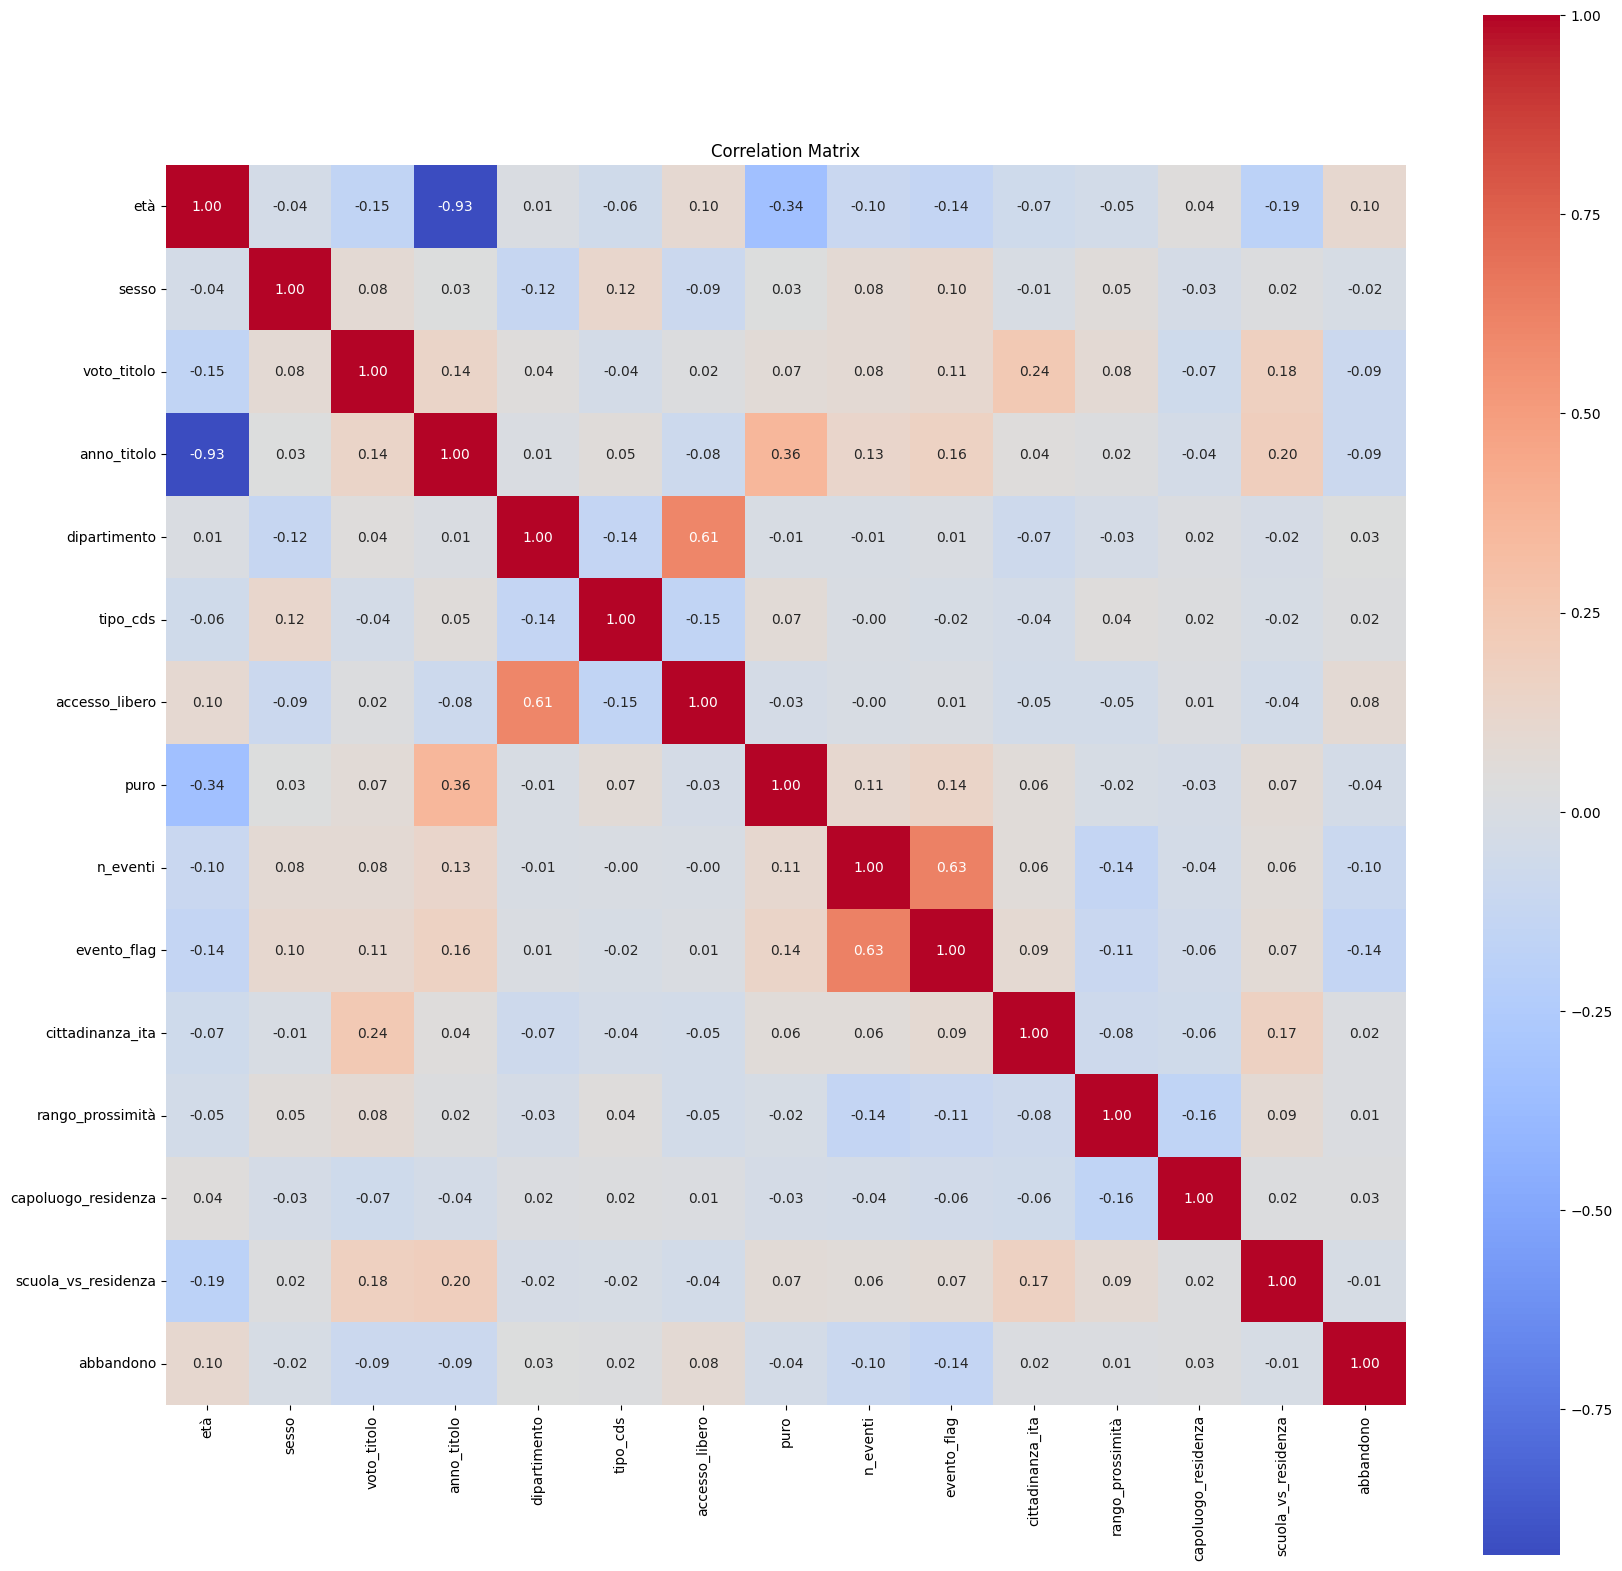

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

target = "abbandono"

correlation_matrix = df.corr(numeric_only=True)

# porta 'abbandono' come ultima colonna/riga
correlation_matrix = correlation_matrix.reindex(
    index=[*correlation_matrix.columns.drop(target), target],
    columns=[*correlation_matrix.columns.drop(target), target]
)

plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix")
plt.show()


Accorgimenti post-analisi + Encoding variabili categoriche

In [5]:
# anno titolo è praticamente uguale a età, lo tolgo. evento binario sembra migliore del suo corrispettivo ordinale
df = df.drop(columns=['anno_titolo', 'n_eventi'])

# poi verifico se c'è qualcosa che mi sfugge nelle colonne
col_check = df.columns.difference(['età'])
for col in col_check:
    print(f"{col}: {df[col].unique()}")

L2_tipo_titolo_new: ['Tecnico_Industriale' 'Scientifico' 'Magistrali' 'Tecnico_Economico'
 'Professionale' 'Artistico' 'Classico' 'Estero' 'Linguistico'
 'Non_fornito']
abbandono: [0 1]
accesso_libero: [1 0]
capoluogo_residenza: [0 1]
cittadinanza_ita: [1 0]
dipartimento: [ 300541  300540  300542  300531  300543  300548   91900 3000547 3000545
 3000546  300528  274007  300529 3000544  300530     426   91100]
evento_flag: [0 1]
lode: ['N' 'S']
puro: [1 0]
rango_prossimità: [1 2 4 0 3 5]
scuola_vs_residenza: [1 0]
sesso: [0 1]
tipo_cds: [0 1]
voto_titolo: [ 64  80 100  87  76  70  73  86  82  60  68  72  62  90  -1  75  97  65
  77  96  85  74  95  78  88  63  84  71  66  83  94  98  93  67  92  69
  79  81  61  91  89  99  55  57  14]


In [6]:
# voto titolo ha dei problemini di registrazione dati :(
# già che ci sono incorporo lode maturità

voto_num = np.where(df["lode"] == "S", 101, df["voto_titolo"]).astype(int)

# maschera validi (tutti tranne -1)
mask_valid = voto_num != -1

# calcolo quartili solo sui valori validi
quartili = pd.qcut(
    voto_num[mask_valid],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"],
    duplicates="drop"
)

# colonna finale: default "assente", riempi con i quartili
df["voto_titolo_new"] = "assente"
df.loc[mask_valid, "voto_titolo_new"] = quartili.astype(str)

# eliminazione delle colonne vecchie finalmente
df = df.drop(columns=["voto_titolo", "lode"])

df['voto_titolo_new'].value_counts()

,count
voto_titolo_new,
Q1,4622
Q3,4234
Q2,3964
Q4,3905
assente,496


In [ ]:
df

,età,sesso,dipartimento,tipo_cds,accesso_libero,puro,abbandono,evento_flag,cittadinanza_ita,rango_prossimità,capoluogo_residenza,scuola_vs_residenza,L2_tipo_titolo_new,voto_titolo_new
0,19,0,300541,0,1,1,0,0,1,1,0,1,Tecnico_Industriale,Q1
1,18,0,300541,0,1,1,1,0,1,1,0,1,Scientifico,Q2
2,20,1,300541,0,1,1,0,1,1,1,0,1,Magistrali,Q4
3,19,1,300541,0,1,1,0,0,1,2,1,1,Tecnico_Economico,Q3
4,40,0,300541,0,1,0,1,0,1,1,0,1,Tecnico_Industriale,Q2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17216,20,1,426,0,0,0,0,0,1,2,0,1,Scientifico,Q4
17217,19,1,426,0,0,1,0,1,1,1,1,0,Estero,assente
17218,20,0,426,0,0,1,0,0,0,1,0,1,Scientifico,Q2
17219,18,1,426,0,0,1,0,0,1,5,0,1,Estero,assente


In [7]:
# ENCODING

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

# Encoding di titolo new
ohe_titolo = OneHotEncoder(sparse_output=False)
encoded_titolo = ohe_titolo.fit_transform(df[['L2_tipo_titolo_new']])
encoded_titolo = pd.DataFrame(
    encoded_titolo,
    columns=ohe_titolo.get_feature_names_out(['L2_tipo_titolo_new']),
    index=df.index
)

# Encoding di voto titolo new
ohe_voto = OneHotEncoder(sparse_output=False)
encoded_voto = ohe_voto.fit_transform(df[['voto_titolo_new']])
encoded_voto = pd.DataFrame(
    encoded_voto,
    columns=ohe_voto.get_feature_names_out(['voto_titolo_new']),
    index=df.index)

# Encoding di dipartimento
le = LabelEncoder()
df['dip_num'] = le.fit_transform(df['dipartimento'])
ohe_dip = OneHotEncoder(sparse_output=False)
encoded_dip = ohe_dip.fit_transform(df[['dip_num']])  # usa la colonna già aggregata
encoded_dip = pd.DataFrame(
    encoded_dip,
    columns=ohe_dip.get_feature_names_out(['dip_num']),
    index=df.index
)

# Drop e concat
df = df.drop(columns=['L2_tipo_titolo_new', 'dipartimento', 'dip_num', 'voto_titolo_new'])
df = pd.concat([df, encoded_titolo, encoded_voto, encoded_dip], axis=1)

df

,età,sesso,tipo_cds,accesso_libero,puro,abbandono,evento_flag,cittadinanza_ita,rango_prossimità,capoluogo_residenza,...,dip_num_7,dip_num_8,dip_num_9,dip_num_10,dip_num_11,dip_num_12,dip_num_13,dip_num_14,dip_num_15,dip_num_16
0,19,0,0,1,1,0,0,1,1,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,18,0,0,1,1,1,0,1,1,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,20,1,0,1,1,0,1,1,1,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,19,1,0,1,1,0,0,1,2,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,40,0,0,1,0,1,0,1,1,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17216,20,1,0,0,0,0,0,1,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17217,19,1,0,0,1,0,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17218,20,0,0,0,1,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17219,18,1,0,0,1,0,0,1,5,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

y = df['abbandono'].astype(int)
df = df.drop(columns=['abbandono'])

# Separazione
num_cols = ["età", "rango_prossimità"]
df_num = df[num_cols]
df_bin = df.drop(columns=num_cols)

# Applichiamo scaling SOLO alle numeriche
scaler = StandardScaler()
df_num_scaled = scaler.fit_transform(df_num)

# Convertiamo di nuovo in DataFrame con i nomi corretti
df_num_scaled = pd.DataFrame(df_num_scaled, columns=num_cols, index=df.index)

# Rimettiamo insieme numeriche scalate + binarie originali
df = pd.concat([df_num_scaled, df_bin], axis=1)

X = df
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

#imputer = IterativeImputer(random_state=42)
#X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
#X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)
X_train.isnull().sum()

,0
età,0
rango_prossimità,0
sesso,0
tipo_cds,0
accesso_libero,0
puro,0
evento_flag,0
cittadinanza_ita,0
capoluogo_residenza,0
scuola_vs_residenza,0


<Axes: ylabel='Frequency'>

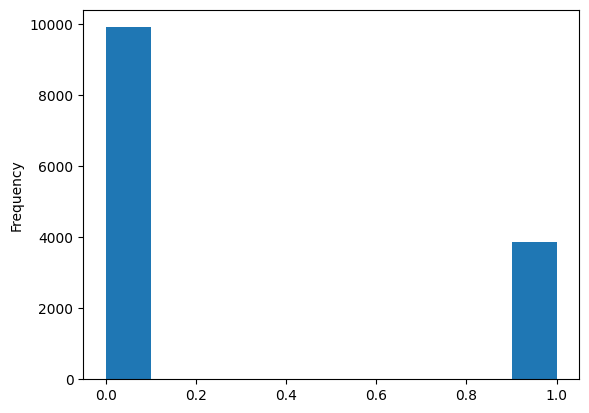

In [9]:
y_train.plot(kind='hist')

# classi sbilanciate. dobbiamo bilanciare prima di applicare modelli

<Axes: ylabel='Frequency'>

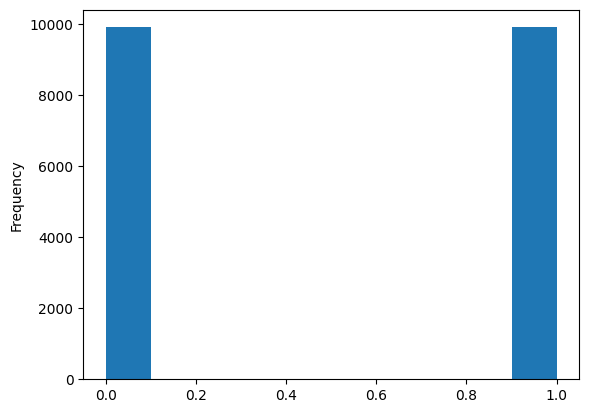

In [10]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
y_train.plot(kind='hist')

## MACHINE LEARNING

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score, accuracy_score
from sklearn.metrics import roc_curve, auc, roc_auc_score, auc



tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
print("TREE REPORT")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, tree.predict_proba(X_test)[:,1]))
print("---------------------------------------------------------------------")

forest = RandomForestClassifier(random_state=42)
forest.fit(X_train, y_train)
y_pred = forest.predict(X_test)
print("RF REPORT")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, forest.predict_proba(X_test)[:,1]))
print("---------------------------------------------------------------------")

xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
print("XGB REPORT")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]))
print("---------------------------------------------------------------------")

logreg = LogisticRegression(max_iter=5000, random_state=42)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
print("LOG-REG REPORT")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, logreg.predict_proba(X_test)[:,1]))
print("---------------------------------------------------------------------")

svm = SVC(probability=True, random_state=42)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
print("SVM REPORT")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, svm.predict_proba(X_test)[:,1]))

TREE REPORT
              precision    recall  f1-score   support

           0       0.75      0.73      0.74      2479
           1       0.35      0.37      0.36       966

    accuracy                           0.63      3445
   macro avg       0.55      0.55      0.55      3445
weighted avg       0.64      0.63      0.63      3445

ROC AUC: 0.5601000787567951
---------------------------------------------------------------------
RF REPORT
              precision    recall  f1-score   support

           0       0.76      0.78      0.77      2479
           1       0.41      0.38      0.39       966

    accuracy                           0.67      3445
   macro avg       0.59      0.58      0.58      3445
weighted avg       0.66      0.67      0.67      3445

ROC AUC: 0.6243739335887292
---------------------------------------------------------------------
XGB REPORT
              precision    recall  f1-score   support

           0       0.78      0.83      0.80      2479
        

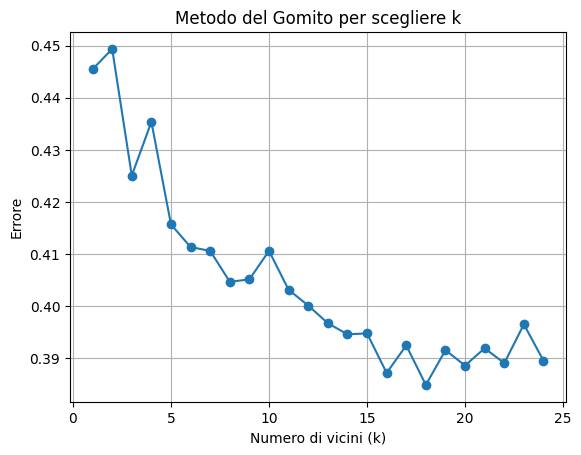

In [12]:
from sklearn.neighbors import KNeighborsClassifier

errori = []
for k in range(1, 25):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    errori.append(1 - roc_auc_score(y_test, y_pred))

plt.plot(range(1, 25), errori, marker='o')
plt.title('Metodo del Gomito per scegliere k')
plt.xlabel('Numero di vicini (k)')
plt.ylabel('Errore')
plt.grid(True)
plt.show()

In [13]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, knn.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.78      0.68      0.73      2479
           1       0.38      0.49      0.43       966

    accuracy                           0.63      3445
   macro avg       0.58      0.59      0.58      3445
weighted avg       0.67      0.63      0.64      3445

ROC AUC: 0.6233387369013585


**Hyperparamter tuning sui modelli migliori**

In [14]:
# import essenziali
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score, fbeta_score,
    confusion_matrix, roc_curve, auc
)
from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier


LOGISTIC REGRESSION HYPERPARAMETERS TUNING

In [15]:
# Modello base (parametri fissi)
logreg = LogisticRegression(
    class_weight='balanced',
    solver='saga',
    max_iter=5000,
    random_state=42
)

# Spazio di ricerca (pulito per evitare warning)
param_dist_log = {
    'C': np.logspace(-3, 3, 50),   # forza regolarizzazione
    'penalty': ['l1', 'l2']        # 'elasticnet' opzionale: vedi nota sotto
}

rand_log = RandomizedSearchCV(
    estimator=logreg,
    param_distributions=param_dist_log,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rand_log.fit(X_train, y_train)
best_logreg = rand_log.best_estimator_

print("LOGREG — migliori parametri:", rand_log.best_params_)
print("LOGREG — ROC AUC (CV):", round(rand_log.best_score_, 3))

# Test @ soglia 0.5
proba_log_test = best_logreg.predict_proba(X_test)[:, 1]
pred_log_05 = (proba_log_test >= 0.5).astype(int)

print("\nLOGREG — TEST @0.5")
print(classification_report(y_test, pred_log_05))
print("ROC AUC (test):", round(roc_auc_score(y_test, proba_log_test), 3))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
LOGREG — migliori parametri: {'penalty': 'l1', 'C': np.float64(0.49417133613238334)}
LOGREG — ROC AUC (CV): 0.698

LOGREG — TEST @0.5
              precision    recall  f1-score   support

           0       0.81      0.60      0.69      2479
           1       0.39      0.64      0.48       966

    accuracy                           0.61      3445
   macro avg       0.60      0.62      0.59      3445
weighted avg       0.69      0.61      0.63      3445

ROC AUC (test): 0.672


XGBOOST — tuning + test @ soglia 0.5

In [16]:
# Stima sbilanciamento (utile per search)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

param_dist_xgb = {
    "n_estimators": np.arange(200, 901, 100),
    "max_depth": np.arange(3, 9),
    "learning_rate": np.logspace(-2, -0.3, 12),
    "subsample": np.linspace(0.6, 1.0, 5),
    "colsample_bytree": np.linspace(0.6, 1.0, 5),
    "min_child_weight": np.arange(1, 11),
    "gamma": np.linspace(0.0, 5.0, 11),
    "reg_lambda": np.logspace(-3, 1, 8),
    "reg_alpha": np.logspace(-4, 1, 8),
    "scale_pos_weight": [spw*0.5, spw, spw*1.5, spw*2]
}

rand_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rand_xgb.fit(X_train, y_train)
best_xgb = rand_xgb.best_estimator_

print("\nXGB — migliori parametri:", rand_xgb.best_params_)
print("XGB — ROC AUC (CV):", round(rand_xgb.best_score_, 3))

# Test @ soglia 0.5
proba_xgb_test = best_xgb.predict_proba(X_test)[:, 1]
pred_xgb_05 = (proba_xgb_test >= 0.5).astype(int)

print("\nXGB — TEST @0.5")
print(classification_report(y_test, pred_xgb_05))
print("ROC AUC (test):", round(roc_auc_score(y_test, proba_xgb_test), 3))


Fitting 5 folds for each of 20 candidates, totalling 100 fits

XGB — migliori parametri: {'subsample': np.float64(0.8), 'scale_pos_weight': np.float64(1.0), 'reg_lambda': np.float64(0.19306977288832497), 'reg_alpha': np.float64(0.002682695795279727), 'n_estimators': np.int64(300), 'min_child_weight': np.int64(4), 'max_depth': np.int64(7), 'learning_rate': np.float64(0.04151278002752295), 'gamma': np.float64(2.0), 'colsample_bytree': np.float64(1.0)}
XGB — ROC AUC (CV): 0.855

XGB — TEST @0.5
              precision    recall  f1-score   support

           0       0.78      0.82      0.80      2479
           1       0.47      0.40      0.43       966

    accuracy                           0.70      3445
   macro avg       0.62      0.61      0.62      3445
weighted avg       0.69      0.70      0.70      3445

ROC AUC (test): 0.685


**OPZIONE B — soglie estreme**

Soglia per F1 (compromesso tra precision e recall)

In [17]:
thr_grid = np.linspace(0, 1, 201)

# LOGREG — F1
f1_scores_log = [f1_score(y_test, (proba_log_test >= t).astype(int)) for t in thr_grid]
thr_log_f1 = thr_grid[int(np.argmax(f1_scores_log))]
pred_log_f1 = (proba_log_test >= thr_log_f1).astype(int)

print(f"\nLOGREG — soglia F1: {thr_log_f1:.3f}")
print(classification_report(y_test, pred_log_f1))

# XGB — F1
f1_scores_xgb = [f1_score(y_test, (proba_xgb_test >= t).astype(int)) for t in thr_grid]
thr_xgb_f1 = thr_grid[int(np.argmax(f1_scores_xgb))]
pred_xgb_f1 = (proba_xgb_test >= thr_xgb_f1).astype(int)

print(f"\nXGB — soglia F1: {thr_xgb_f1:.3f}")
print(classification_report(y_test, pred_xgb_f1))



LOGREG — soglia F1: 0.395
              precision    recall  f1-score   support

           0       0.85      0.41      0.55      2479
           1       0.35      0.81      0.49       966

    accuracy                           0.52      3445
   macro avg       0.60      0.61      0.52      3445
weighted avg       0.71      0.52      0.53      3445


XGB — soglia F1: 0.345
              precision    recall  f1-score   support

           0       0.82      0.58      0.68      2479
           1       0.38      0.68      0.49       966

    accuracy                           0.60      3445
   macro avg       0.60      0.63      0.58      3445
weighted avg       0.70      0.60      0.62      3445



Soglia per F2 (recall prioritaria)

In [18]:
# LOGREG — F2
f2_scores_log = [fbeta_score(y_test, (proba_log_test >= t).astype(int), beta=2) for t in thr_grid]
thr_log_f2 = thr_grid[int(np.argmax(f2_scores_log))]
pred_log_f2 = (proba_log_test >= thr_log_f2).astype(int)

print(f"\nLOGREG — soglia F2: {thr_log_f2:.3f}")
print(classification_report(y_test, pred_log_f2))

# XGB — F2
f2_scores_xgb = [fbeta_score(y_test, (proba_xgb_test >= t).astype(int), beta=2) for t in thr_grid]
thr_xgb_f2 = thr_grid[int(np.argmax(f2_scores_xgb))]
pred_xgb_f2 = (proba_xgb_test >= thr_xgb_f2).astype(int)

print(f"\nXGB — soglia F2: {thr_xgb_f2:.3f}")
print(classification_report(y_test, pred_xgb_f2))



LOGREG — soglia F2: 0.215
              precision    recall  f1-score   support

           0       0.92      0.11      0.20      2479
           1       0.30      0.98      0.46       966

    accuracy                           0.36      3445
   macro avg       0.61      0.54      0.33      3445
weighted avg       0.75      0.36      0.27      3445


XGB — soglia F2: 0.140
              precision    recall  f1-score   support

           0       0.91      0.16      0.27      2479
           1       0.31      0.96      0.47       966

    accuracy                           0.38      3445
   macro avg       0.61      0.56      0.37      3445
weighted avg       0.74      0.38      0.33      3445



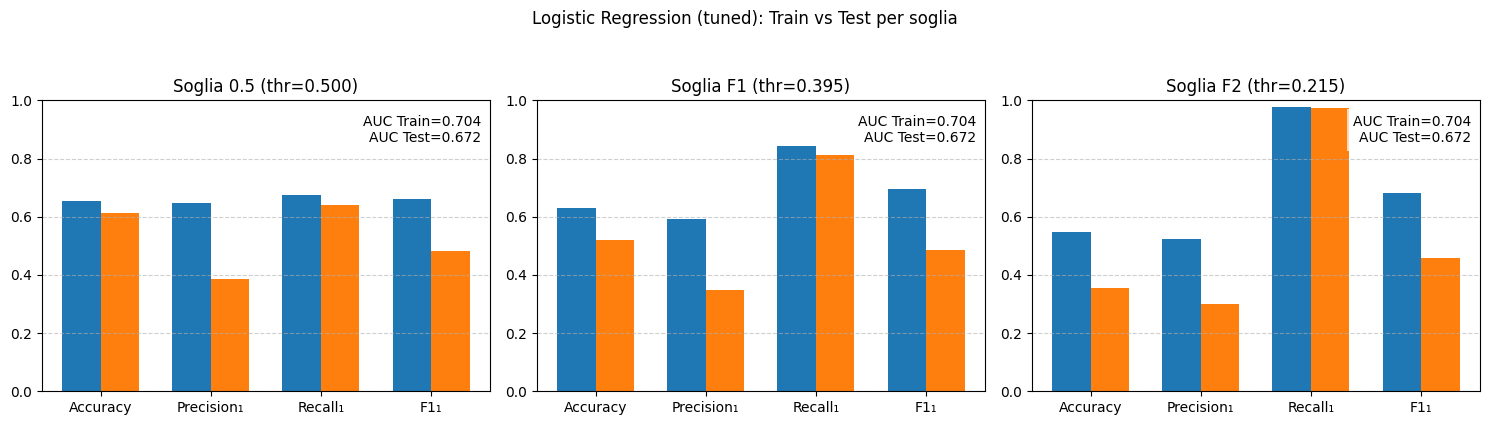

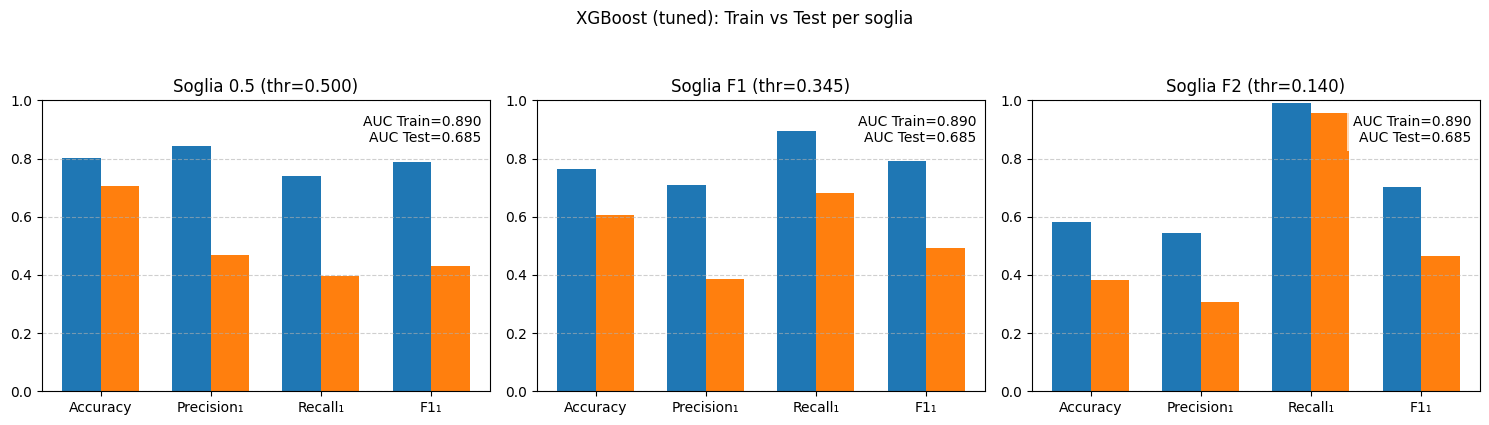

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# === Probabilità su TRAIN/TEST ===
proba_log_train = best_logreg.predict_proba(X_train)[:, 1]
proba_log_test  = best_logreg.predict_proba(X_test)[:, 1]
proba_xgb_train = best_xgb.predict_proba(X_train)[:, 1]
proba_xgb_test  = best_xgb.predict_proba(X_test)[:, 1]

# === Utility: trova soglia che massimizza F1/F2 se non già note ===
def best_threshold(y_true, proba, beta=1, grid=np.linspace(0,1,201)):
    scores = []
    if beta == 1:
        for t in grid: scores.append(f1_score(y_true, (proba >= t).astype(int)))
    else:
        from sklearn.metrics import fbeta_score
        for t in grid: scores.append(fbeta_score(y_true, (proba >= t).astype(int), beta=beta))
    i = int(np.argmax(scores))
    return float(grid[i])

# Calcola soglie F1/F2 su TEST (come nelle tue valutazioni)
try:
    thr_log_f1
except NameError:
    thr_log_f1 = best_threshold(y_test, proba_log_test, beta=1)
try:
    thr_log_f2
except NameError:
    thr_log_f2 = best_threshold(y_test, proba_log_test, beta=2)

try:
    thr_xgb_f1
except NameError:
    thr_xgb_f1 = best_threshold(y_test, proba_xgb_test, beta=1)
try:
    thr_xgb_f2
except NameError:
    thr_xgb_f2 = best_threshold(y_test, proba_xgb_test, beta=2)

# === Utility: metriche per una soglia ===
def metrics_at(y_true, proba, thr):
    y_pred = (proba >= thr).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision₁": precision_score(y_true, y_pred, zero_division=0),
        "Recall₁": recall_score(y_true, y_pred),
        "F1₁": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, proba),
    }

# === Plot: tre soglie (0.5, F1, F2) — Train vs Test per 4 metriche + AUC ===
def plot_train_test(model_name, y_tr, p_tr, y_te, p_te, thr_05, thr_f1, thr_f2):
    thresholds = {
        "0.5": thr_05,
        "F1":  thr_f1,
        "F2":  thr_f2
    }
    metrics = ["Accuracy", "Precision₁", "Recall₁", "F1₁"]  # AUC a parte

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
    for ax, (label, thr) in zip(axes, thresholds.items()):
        mt_tr = metrics_at(y_tr, p_tr, thr)
        mt_te = metrics_at(y_te, p_te, thr)

        x = np.arange(len(metrics))
        width = 0.35
        ax.bar(x - width/2, [mt_tr[m] for m in metrics], width, label="Train")
        ax.bar(x + width/2, [mt_te[m] for m in metrics], width, label="Test")

        ax.set_xticks(x)
        ax.set_xticklabels(metrics, rotation=0)
        ax.set_ylim(0, 1)
        ax.set_title(f"Soglia {label} (thr={thr:.3f})")
        ax.grid(axis="y", linestyle="--", alpha=.6)

        # Mostra AUC come testo in alto a destra del pannello
        ax.text(0.98, 0.95,
                f"AUC Train={mt_tr['AUC']:.3f}\nAUC Test={mt_te['AUC']:.3f}",
                transform=ax.transAxes, ha="right", va="top",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
    fig.suptitle(f"{model_name}: Train vs Test per soglia", y=1.05, fontsize=12)
    fig.tight_layout()
    plt.show()

# === LOGREG: grafico Train vs Test alle tre soglie ===
plot_train_test(
    "Logistic Regression (tuned)",
    y_train, proba_log_train, y_test, proba_log_test,
    thr_05=0.5, thr_f1=thr_log_f1, thr_f2=thr_log_f2
)

# === XGB: grafico Train vs Test alle tre soglie ===
plot_train_test(
    "XGBoost (tuned)",
    y_train, proba_xgb_train, y_test, proba_xgb_test,
    thr_05=0.5, thr_f1=thr_xgb_f1, thr_f2=thr_xgb_f2
)


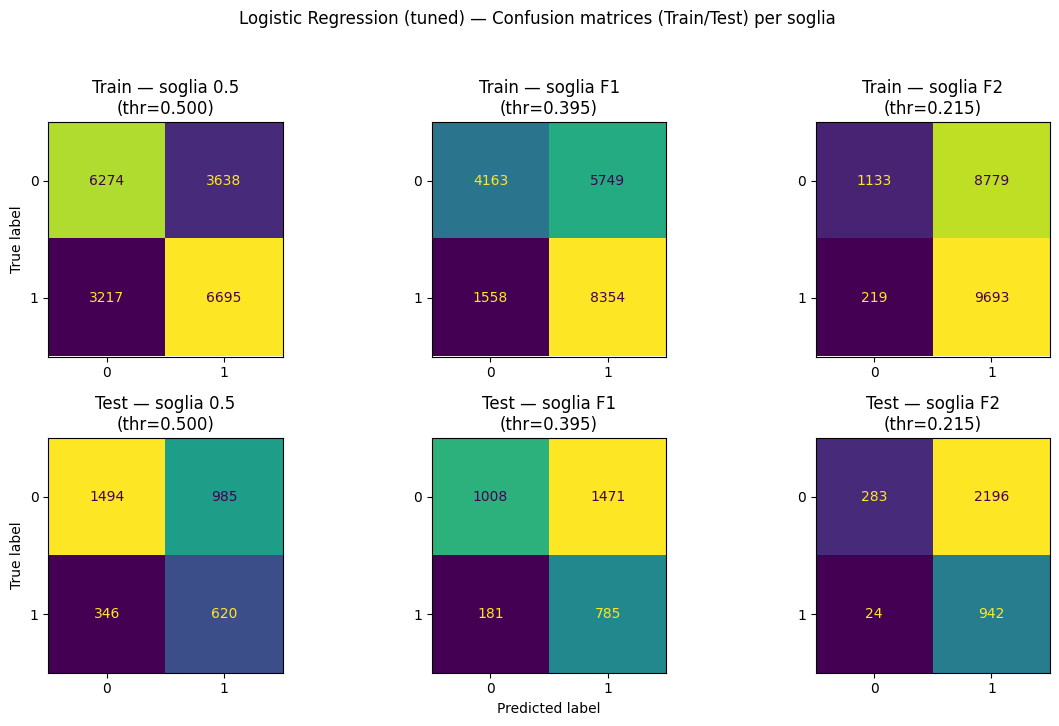

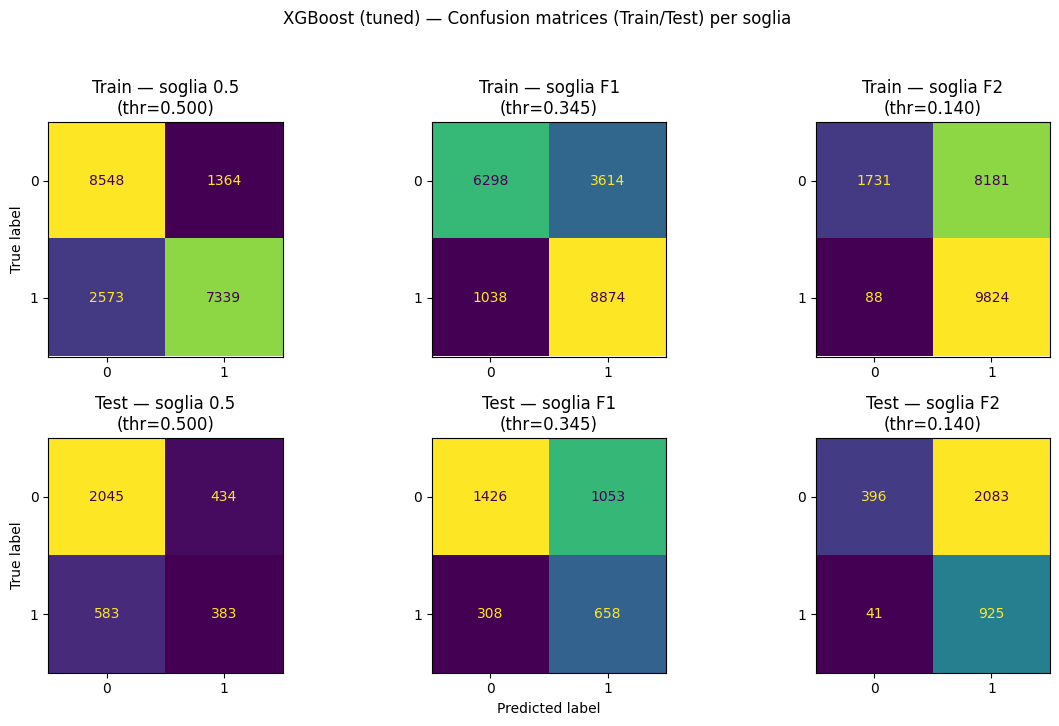

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, fbeta_score

# === Probabilità su TRAIN/TEST ===
proba_log_train = best_logreg.predict_proba(X_train)[:, 1]
proba_log_test  = best_logreg.predict_proba(X_test)[:, 1]
proba_xgb_train = best_xgb.predict_proba(X_train)[:, 1]
proba_xgb_test  = best_xgb.predict_proba(X_test)[:, 1]

# === Utility: trova soglia che massimizza F1/F2 (se non già definite) ===
def best_threshold(y_true, proba, beta=1, grid=np.linspace(0,1,201)):
    scores = []
    if beta == 1:
        for t in grid: scores.append(f1_score(y_true, (proba >= t).astype(int)))
    else:
        for t in grid: scores.append(fbeta_score(y_true, (proba >= t).astype(int), beta=beta))
    i = int(np.argmax(scores))
    return float(grid[i])

# Calcola soglie su TEST se mancano
try: thr_log_f1
except NameError: thr_log_f1 = best_threshold(y_test, proba_log_test, beta=1)
try: thr_log_f2
except NameError: thr_log_f2 = best_threshold(y_test, proba_log_test, beta=2)
try: thr_xgb_f1
except NameError: thr_xgb_f1 = best_threshold(y_test, proba_xgb_test, beta=1)
try: thr_xgb_f2
except NameError: thr_xgb_f2 = best_threshold(y_test, proba_xgb_test, beta=2)

# === Plot grid confusion matrices ===
def plot_confusion_grid(model_name, y_tr, p_tr, y_te, p_te, thr_05, thr_f1, thr_f2):
    thresholds = [("0.5", thr_05), ("F1", thr_f1), ("F2", thr_f2)]

    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    for j, (label, thr) in enumerate(thresholds):
        # TRAIN
        y_pred_tr = (p_tr >= thr).astype(int)
        cm_tr = confusion_matrix(y_tr, y_pred_tr)
        disp_tr = ConfusionMatrixDisplay(cm_tr, display_labels=[0,1])
        disp_tr.plot(ax=axes[0, j], colorbar=False)
        axes[0, j].set_title(f"Train — soglia {label}\n(thr={thr:.3f})")
        axes[0, j].set_xlabel(""); axes[0, j].set_ylabel("")

        # TEST
        y_pred_te = (p_te >= thr).astype(int)
        cm_te = confusion_matrix(y_te, y_pred_te)
        disp_te = ConfusionMatrixDisplay(cm_te, display_labels=[0,1])
        disp_te.plot(ax=axes[1, j], colorbar=False)
        axes[1, j].set_title(f"Test — soglia {label}\n(thr={thr:.3f})")
        axes[1, j].set_xlabel(""); axes[1, j].set_ylabel("")

    # Etichette comuni
    axes[1, 1].set_xlabel("Predicted label")
    axes[0, 0].set_ylabel("True label")
    axes[1, 0].set_ylabel("True label")

    fig.suptitle(f"{model_name} — Confusion matrices (Train/Test) per soglia", y=1.03, fontsize=12)
    plt.tight_layout()
    plt.show()

# === LOGREG: CM Train/Test a 0.5, F1, F2 ===
plot_confusion_grid(
    "Logistic Regression (tuned)",
    y_train, proba_log_train, y_test, proba_log_test,
    thr_05=0.5, thr_f1=thr_log_f1, thr_f2=thr_log_f2
)

# === XGB: CM Train/Test a 0.5, F1, F2 ===
plot_confusion_grid(
    "XGBoost (tuned)",
    y_train, proba_xgb_train, y_test, proba_xgb_test,
    thr_05=0.5, thr_f1=thr_xgb_f1, thr_f2=thr_xgb_f2
)

# matrici normalizzate a 100
# cm_tr = confusion_matrix(y_tr, y_pred_tr, normalize='true')
# cm_te = confusion_matrix(y_te, y_pred_te, normalize='true')



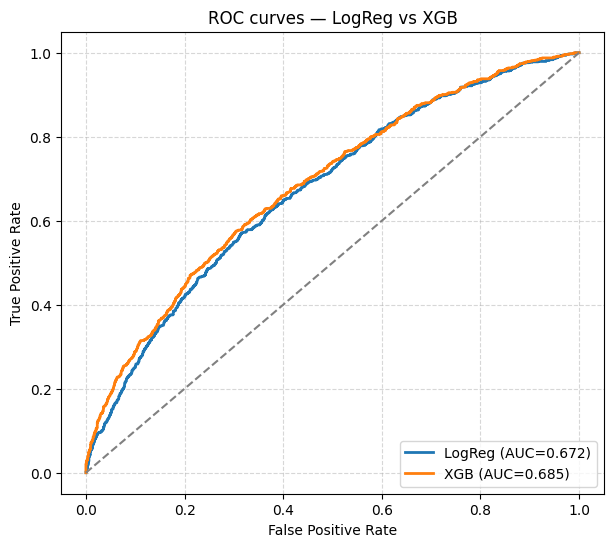

In [22]:
fpr_log, tpr_log, _ = roc_curve(y_test, proba_log_test)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, proba_xgb_test)

auc_log = auc(fpr_log, tpr_log)
auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(7,6))
plt.plot(fpr_log, tpr_log, lw=2, label=f"LogReg (AUC={auc_log:.3f})")
plt.plot(fpr_xgb, tpr_xgb, lw=2, label=f"XGB (AUC={auc_xgb:.3f})")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves — LogReg vs XGB')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=.5)
plt.show()

## Explainability

**EXPLAINABILITY per i modelli raccomandati**

XGB (tuned, soglia F1) come “best trade-off” e LogReg (tuned) come baseline interpretabile

SHAP summary (globale) per XGB

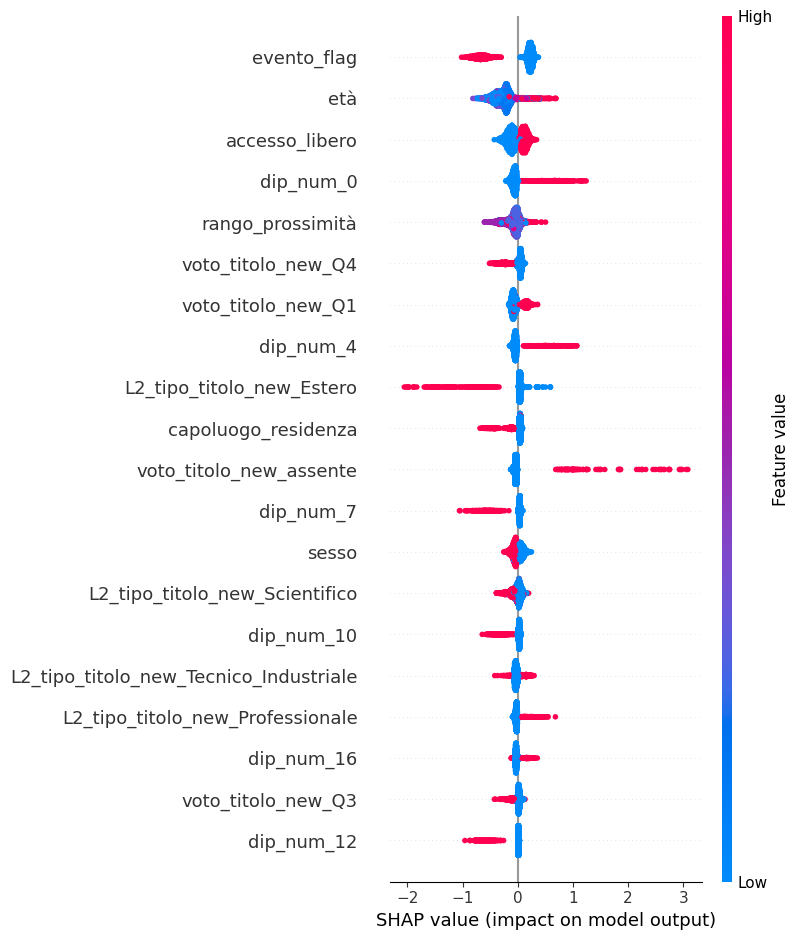

In [23]:
import shap
shap_explainer = shap.TreeExplainer(best_xgb)
shap_values = shap_explainer.shap_values(X_test)

# Se X_test è DataFrame, SHAP mostra i nomi; altrimenti bisogna convertire a DF con nomi colonne.
shap.summary_plot(shap_values, X_test)   # occhio perché backend grafico attivo

Coefficienti top (LogReg) — bar chart

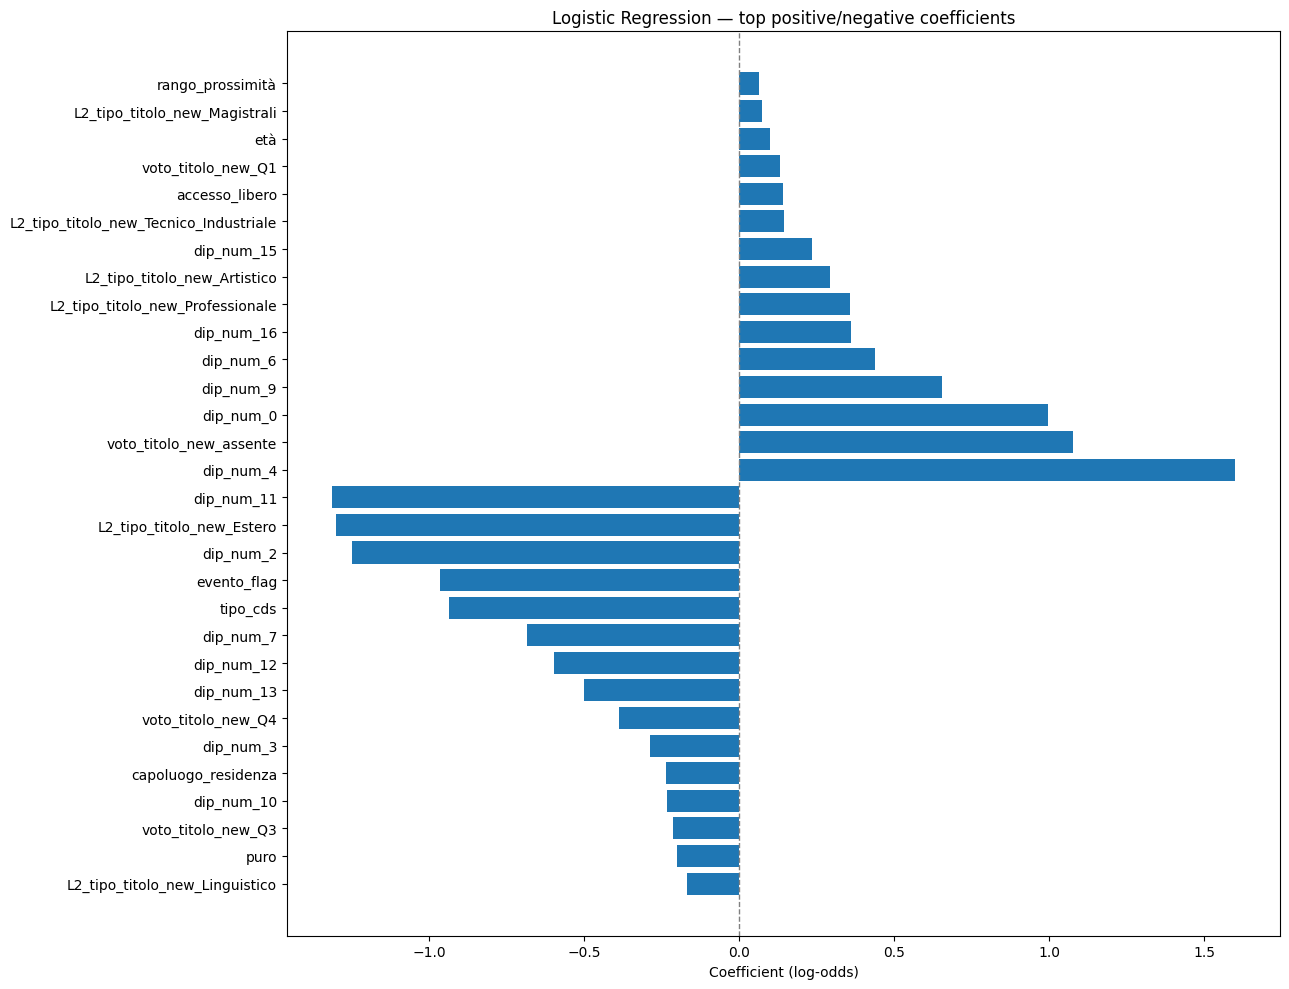

In [24]:
feat_names = list(X_train.columns)
coef = best_logreg.coef_.ravel()
odds_ratio = np.exp(coef)

coef_df = (
    pd.DataFrame({"feature": feat_names, "coef": coef, "odds_ratio": odds_ratio})
    .sort_values("coef", ascending=False)
)

k = 15
top_pos = coef_df.head(k)
top_neg = coef_df.tail(k)
plot_df = pd.concat([top_neg, top_pos])

plt.figure(figsize=(13, 10))
plt.barh(plot_df["feature"], plot_df["coef"])
plt.axvline(0, linestyle='--', linewidth=1, color='gray')
plt.xlabel("Coefficient (log-odds)")
plt.title("Logistic Regression — top positive/negative coefficients")
plt.tight_layout()
plt.show()